# Let's compute the Bellman-Ford Shortest Path
In this activity, we'll build random graphs of different sizes and measure the performance of the Bellman-Ford algorithm on them. However, there is a wrinkle. Instead of [using `VLDataScienceMachineLearningPackage.jl`](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), we'll use [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl) directly to create and manipulate our graphs. 

> __Why Graphs.jl?__ This is yet another example of the __buy versus build__ tradeoff. [The `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) provides a high-level interface for working with graphs, including functions for creating, manipulating, and traversing them. However, we could also use existing packages [like `Graphs.jl`](https://github.com/JuliaGraphs/Graphs.jl) to achieve similar results (and perhaps do other things). Let's check out this package!

So let's go!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [1]:
include(joinpath(@__DIR__, "Include-ShortestPath-Graded-Codio.jl"));

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

## Task 1: Let's use Graphs.jl to build and visualize a collection of random graphs
In this task, let's use [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl) to create some random graphs, and [the `Karnak.jl` package](https://github.com/cormullion/Karnak.jl) to visualize them. 

> __What are we doing?__ We are going to generate random [scale free graphs](https://en.wikipedia.org/wiki/Barabási–Albert_model) using the `barabasi_albert` function from the `Graphs.jl` package. Scale-free graphs are a type of network that exhibit a power-law degree distribution, meaning that a few nodes have a very high degree (many connections), while most nodes have a low degree (few connections). This property is often observed in real-world networks, such as social networks, biological networks, and the internet.

Our scale-free graphs will have a range of sizes and connection patterns, where every edge has a weight of `1`, allowing us to explore the behavior of shortest path algorithms on different networks.

In [2]:
graph_collection_dictionary = let

    # initialize -
    graph_collection_dictionary = Dict{Tuple{Int,Int}, AbstractGraph}();
    n = 10:10:40 |> collect;
    k = 2:2:10 |> collect;
    isdirected = false; # you can change this to true if you want directed graphs!

    for i ∈ eachindex(n)
        for j ∈ eachindex(k)            
            # build graph -
            g = barabasi_albert(n[i], k[j], is_directed = isdirected);

            # store in dictionary -
            graph_collection_dictionary[(n[i], k[j])] = g;
        end
    end

    # check: sometimes, we get nodes with no edges, get rid of these cases
    for (key, g) ∈ graph_collection_dictionary
        if ne(g) == 0 # where is ne(g) defined?
            delete!(graph_collection_dictionary, key);
        end
    end

    graph_collection_dictionary; # return
end

Dict{Tuple{Int64, Int64}, AbstractGraph} with 19 entries:
  (20, 4)  => SimpleGraph{Int64}(64, [[5, 6, 8, 9, 13, 14], [5, 6, 7, 11, 17], …
  (30, 4)  => SimpleGraph{Int64}(104, [[5, 6, 7, 8, 19, 27], [5, 6, 11, 16, 18]…
  (40, 6)  => SimpleGraph{Int64}(204, [[7, 8, 9, 10, 11, 12, 13, 19, 24, 25, 33…
  (10, 6)  => SimpleGraph{Int64}(24, [[7, 8, 9, 10], [7, 8], [7, 8, 9], [7, 8, …
  (20, 6)  => SimpleGraph{Int64}(84, [[7, 8, 9, 10, 11, 12, 13, 18], [7, 8, 9, …
  (40, 8)  => SimpleGraph{Int64}(256, [[9, 11, 12, 15], [9, 10, 11, 15, 17, 20,…
  (40, 10) => SimpleGraph{Int64}(300, [[11, 12, 13, 17, 20, 32], [11, 12, 13, 1…
  (40, 2)  => SimpleGraph{Int64}(76, [[3, 15], [3, 4, 5, 19], [1, 2, 4, 5, 6, 7…
  (30, 6)  => SimpleGraph{Int64}(144, [[7, 8, 13, 17, 28], [7, 8, 9, 10, 15, 16…
  (10, 8)  => SimpleGraph{Int64}(16, [[9], [9, 10], [9, 10], [9, 10], [9, 10], …
  (10, 2)  => SimpleGraph{Int64}(16, [[3, 4, 6, 8, 10], [3, 4, 5, 6, 8, 9], [1,…
  (40, 4)  => SimpleGraph{Int64}(144, [[5, 6, 8, 9,

Now, let's select a random graph, and visualize it.

> __Wow!__ We've chained together several commands using [the `|>` operation](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping) like a Julia Ninja to ultimately arrive at a random graph selected from our graph collection which we save in the `g` variable. This graph will be a different type depending on whether we selected directed or undirected graph using the `isdirected::Bool` value.

Our random graph will be in the `g` variable.

In [3]:
g = keys(graph_collection_dictionary) |> collect |> rand |> i-> graph_collection_dictionary[i]

{10, 24} undirected simple Int64 graph

We've seen the fields of the graph model implemented in [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), however, what fields are in the graph models exported by [the `Graphs.jl` package](https://github.com/JuliaGraphs/Graphs.jl)? 

To answer this question, let's [use the `typeof(...)` function](https://docs.julialang.org/en/v1/base/base/#Core.typeof) in combination with [the `fieldnames(...)` function](https://docs.julialang.org/en/v1/base/base/#Base.fieldnames) to inspect the structure of a graph object created using the `Graphs.jl` package.

In [4]:
typeof(g) |> T -> fieldnames(T)

(:ne, :fadjlist)

Let's dig into the fields of the graph model `g`.
* __ne::Int64:__ is the number of edges contained in the random graph `g <: AbstractGraph`, i.e., the graph `g` is a subtype of `AbstractGraph`, either a `SimpleGraph` if undirected, or a `SimpleDiGraph` if directed.
* __fadjlist::Array{Array{Int64}}:__ is an array of `Array{Int64}` types, i.e., an array of arrays, where the array at element $i$ holds the list of children of node $i$. Thus, if we wanted to check for a parent-child relationship between node $i$ and node $j$, we could see if node $j$ was an element of the children list of node $i$. I wish it were a `Set{Int64}` instead of an array, but perhaps that is just me.

Use the Julia dot syntax to access these fields, for example `g.ne` to get the number of edges, or `g.fadjlist` to get the adjacency list.

In [5]:
g.fadjlist # what is this?

10-element Vector{Vector{Int64}}:
 [5, 6, 7, 8, 9]
 [5]
 [5, 6, 9]
 [5, 6, 7, 8, 10]
 [1, 2, 3, 4, 6, 7, 9, 10]
 [1, 3, 4, 5, 7, 8, 9, 10]
 [1, 4, 5, 6, 8]
 [1, 4, 6, 7, 10]
 [1, 3, 5, 6]
 [4, 5, 6, 8]

`Unhide` the code block below to see how we visualized the random graph selected from our collection of graphs [using the `Karnak.jl` package](https://github.com/cormullion/Karnak.jl).

> __Caution:__ The [`Karnak.jl` package](https://github.com/cormullion/Karnak.jl) uses some advanced features of the Julia programming language, e.g., [macros](https://docs.julialang.org/en/v1/manual/metaprogramming/#man-macros), which may not be familiar to all users. This example also uses some next generation syntax, so don't be confused if you see something you don't recognize!

While a little complicated, this package produces some cool visualizations of graphs!

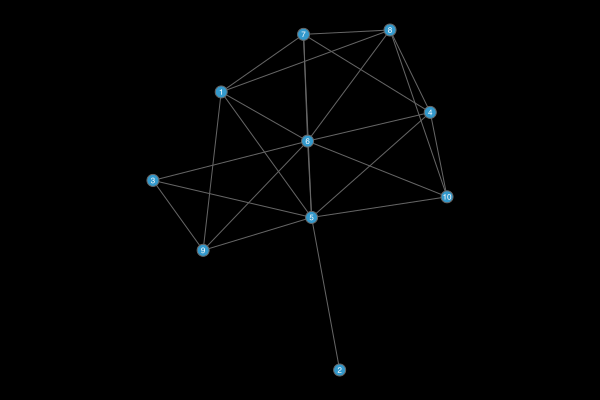

In [6]:
let
    @drawsvg begin
    background("black")
    sethue("grey40")
    fontsize(8)
    drawgraph(g, 
        layout=stress, 
        vertexlabels = 1:nv(g),
        vertexfillcolors = 
            [RGB(0.2,0.6,0.8) 
               for i in 1:nv(g)]
    )
    end 600 400
end

## Task 2: Let's compute the shortest path on our random graph
In this task, we'll compute the shortest path to all other nodes starting from node `1` using the Bellman-Ford algorithm. However, unlike our previous examples that used [the `findshortestpath(...)` function exported by the `VLDataScienceMachineLearningPackage.jl` package ](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/graphs/#VLDataScienceMachineLearningPackage.findshortestpath), we will call [the `bellman_ford_shortest_paths(...)` function from the `Graphs.jl` package](https://juliagraphs.org/Graphs.jl/stable/algorithms/shortestpaths/#Graphs.bellman_ford_shortest_paths-Union{Tuple{T},%20Tuple{U},%20Tuple{AbstractGraph{U},%20AbstractVector{%3C:Integer}},%20Tuple{AbstractGraph{U},%20AbstractVector{%3C:Integer},%20AbstractMatrix{T}}}%20where%20{U%3C:Integer,%20T%3C:Number}).

This implementation takes a graph instance, and a start node index. However, this method returns a more complicated data structure that includes not only the distances but also the predecessor information for each node, which can be used to reconstruct the shortest paths which is an instance of type [`Graphs.BellmanFordState{Int64, Int64}`](https://juliagraphs.org/Graphs.jl/stable/algorithms/shortestpaths/#Graphs.BellmanFordState). 

Let's run the shortest path calculation, and save the result in the `result::Graphs.BellmanFordState{Int64, Int64}` variable.

In [7]:
result = bellman_ford_shortest_paths(g, 1);

What are the fields of the `Graphs.BellmanFordState{Int64, Int64}` type?

In [8]:
typeof(result) |> T -> fieldnames(T)

(:parents, :dists)

Let's dig into the fields of the `result` variable.
* __parents::Array{Int64,1}:__ The parents field holds the predecessor information for each node, which can be used to reconstruct the shortest paths. For example, the first node (at index `1`) has no parent (it is the source node), so its parent is `0`. However, node `2` is a child of node `5` on the shortest path. The `parents` array can be used to trace back the shortest path from any node to the source node, and should have the same length as the number of nodes in the graph.
* __dists::Array{Int64,1}:__ The dists field holds the shortest path distances from the source node to each other node. If a node is unreachable from the source, its distance will be set to `Inf`. For example, from node `1` to node `1` has a distance of `0`, while from node `1` to node `2` has a distance of `2`, etc.

Use the Julia dot syntax to access these fields, for example `result.parents` to get the parents array, or `result.dists` to get the distances array.

In [9]:
result.dists

10-element Vector{Int64}:
 0
 2
 2
 2
 1
 1
 1
 1
 1
 2

### How should we think about the `dists` field?
The `dists` field represents the shortest path distances from the source node (in this case `1`) to each other node in the graph. Each entry in the `dists` array corresponds to a node in the graph, and the value at that entry indicates the minimum distance from the source node to that node.

> __Check:__ If a node has a distance of `1` from the source node, it means that it is directly connected to the source node by an edge with a weight of `1`. We can check this by looking at the graph structure and the weights of the edges.

First, let's find all the nodes that have a distance of `1` from the source node. If our logic is correct, these should be children of the source node.

In [10]:
nodes_set_distance_1 = let

    # initialiaze -
    node_set = Set{Int64}();

    for i ∈ eachindex(result.dists)
        if result.dists[i] == 1
            push!(node_set, i);
        end
    end

    node_set # return
end

Set{Int64} with 5 elements:
  5
  6
  7
  9
  8

Ok, so next, let's grab the children of the source node from the `g.fadjlist` field.
> __Note:__ By default we assume the graph is __undirected__, meaning that if there is an edge from node `u` to node `v`, there is also an edge from node `v` to node `u`. Thus, the `g` instance will only have a `fadjlist` field for each node, which contains the list of its neighbors. If the graph is directed, there may be additional connectivity information stored in the `g` instance.

Let's save the children in the `children::Set{Int64}` variable.

In [11]:
children = let
    children = Set(g.fadjlist[1]); # children of node 1
end

Set{Int64} with 5 elements:
  5
  6
  7
  9
  8

Finally, let's compare the two sets:

In [12]:
@test nodes_set_distance_1 == children

Test Passed

## Task 3: Let's compute the scaling behavior of the Bellman-Ford Shortest Path Algorithm
In this task, we'll compute the scaling behavior of the Bellman-Ford Shortest Path Algorithm by measuring its performance on random graphs of different sizes.
> __Complexity__: The time complexity of the Bellman-Ford algorithm is $\mathcal{O}(|\mathcal{V}|\cdot|\mathcal{E}|)$, where $|\mathcal{E}|$ is the number of edges and $|\mathcal{V}|$ is the number of vertices in the graph. This is because we iterate through all edges $|\mathcal{V}| - 1$ times.

We'll start by computing an order (or scaling) parameter that is the product of the number of vertices and the number of edges in the graph. We'll store this in the `order_parameter_dictionary::Dict{Tuple{Int,Int}, Int}` dictionary.

In [13]:
order_parameter_dictionary = let

    # initialize -
    order_parameter_dictionary = Dict{Tuple{Int,Int}, Int}();

    for (key, g) ∈ graph_collection_dictionary
        order_parameter_dictionary[key] = nv(g) * ne(g);
    end

    order_parameter_dictionary; # return
end

Dict{Tuple{Int64, Int64}, Int64} with 19 entries:
  (20, 4)  => 1280
  (30, 4)  => 3120
  (40, 6)  => 8160
  (10, 6)  => 240
  (20, 6)  => 1680
  (40, 8)  => 10240
  (40, 10) => 12000
  (40, 2)  => 3040
  (30, 6)  => 4320
  (10, 8)  => 160
  (10, 2)  => 160
  (40, 4)  => 5760
  (10, 4)  => 240
  (20, 8)  => 1920
  (20, 10) => 2000
  (20, 2)  => 720
  (30, 8)  => 5280
  (30, 10) => 6000
  (30, 2)  => 1680

For each graph in our collection, we calculate the order parameter (the product of the number of vertices and edges, `nv(g) * ne(g)`) and use it as the key in the dictionary. The value associated with each key is the mean execution time of the Bellman-Ford algorithm on that graph. 

> __Benchmarking the algorithm:__ To measure the execution time, we use the `@benchmark` macro, which runs the Bellman-Ford algorithm multiple times on the graph and collects timing data. The `mean(results.times)` gives us the average execution time in nanoseconds, which we store in the dictionary. This allows us to analyze how the algorithm's runtime scales with the size and density of the graph.

By organizing the data in this way, we can easily compare the runtime of the algorithm across graphs of different sizes and structures. This helps us validate the theoretical complexity of Bellman-Ford and understand its performance in practice.

In [ ]:
mean_time_dictionary = let

    # This code benchmarks the Bellman-Ford algorithm on each graph in our collection
    # and stores the mean execution time keyed by the order parameter (nv * ne)
    # initialize -
    mean_time_dictionary = Dict{Int64, Float64}();

    for (key, g) ∈ graph_collection_dictionary
        order_parameter_value = order_parameter_dictionary[key];
        results = @benchmark bellman_ford_shortest_paths(graph, 1) setup=(graph=$g);
        mean_time_dictionary[order_parameter_value] = mean(results.times);
    end

    mean_time_dictionary; # return
end

Dict{Int64, Float64} with 16 entries:
  8160  => 448.371
  1920  => 257.082
  720   => 193.212
  160   => 139.258
  6000  => 407.175
  5280  => 383.377
  2000  => 262.239
  3040  => 334.586
  10240 => 515.873
  5760  => 386.91
  12000 => 539.903
  4320  => 347.787
  1280  => 222.241
  240   => 144.772
  1680  => 269.105
  3120  => 314.836

`Unhide` the code below to see how we visualized the mean timing results for the Bellman-Ford algorithm on random scale-free networks.

In [ ]:
let

    # initialize -
    lineplotdata = Array{Float64,2}(undef, length(mean_time_dictionary), 2);
    orderarray = collect(keys(mean_time_dictionary)) |> sort;

    for i ∈ eachindex(orderarray)
        lineplotdata[i, 1] = orderarray[i] # n
        lineplotdata[i, 2] = mean_time_dictionary[orderarray[i]]; # mean time
    end

    # Old school plotting!
    plt = scatterplot(lineplotdata[:,1], lineplotdata[:,2], xlabel="Order Parameter (n * m)", ylabel="Mean Time (ns)", title="Mean Time vs Order Parameter", legend=false)
    lineplot!(plt, lineplotdata[:,1], lineplotdata[:,2])
end

                      ⠀⠀⠀⠀⠀⠀⠀Mean Time vs Order Parameter⠀⠀⠀⠀⠀⠀⠀ 
                      ┌────────────────────────────────────────┐ 
                  600 │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⠔⠊⠉⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⠔⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⠔⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⡠⠒⠉⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⠔⠚⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
   Mean Time (ns)     │⠀⠀⠀⠀⠀⠀⡀⢀⠤⠊⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⠀⠀⡜⠗⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⠀⡀⡜⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⠀⢠⠛⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⠀⢀⠞⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
                      │⢀⠇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀│ 
          

__What do we see?__ The scatter plot shows a clear trend: as the order parameter $(n\times{m})$ increases, the mean execution time of the Bellman-Ford algorithm also increases. This makes sense because the algorithm's time complexity is $\mathcal{O}(|\mathcal{V}| \cdot |\mathcal{E}|)$, meaning that larger graphs with more vertices and edges require more computational work.

> __Scaling behavior:__ The roughly linear relationship between the order parameter and the mean time aligns with the theoretical complexity. However, you might notice some scatter in the data points. This variation is due to differences in the structure of the random graphs — for example, some graphs may have more densely connected regions, which can slightly affect performance.

> __Takeaway:__ While Bellman-Ford is reliable and handles negative edge weights, its performance can become a bottleneck for large or dense graphs. For graphs with non-negative weights, Dijkstra's algorithm is often a better choice due to its faster runtime. However, Bellman-Ford remains an essential tool for scenarios where negative weights are present or when simplicity is preferred.